# Demo. Test Two Patch Lattice Surgery

In [1]:
import sys
from pathlib import Path

ROOT = Path('../..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import stim

from lightstim.qec_code.surface_code.unrotated import (
    UnrotatedSurfaceCode,
    UnrotatedSurfaceCodeExtractionBlock,
    UnrotatedTwoPatchCoupler,
)
from lightstim.protocols.two_patch_ls import TwoPatchLSExperiment

## Two Patch LS. Unrotated Surface Code

For XX/ZZ measurement experiments, the initialization basis and the measurement basis are the same.  
For teleportation experiments (Patch 1 -> Patch 2), the measurement basis can be different from the initialization basis. The protocol is:  
(1) Patch 2 in $|+\rangle$ -> ZZ measurement + X measurement on Patch 1;  
(2) Patch 2 in $|0\rangle$ -> XX measurement + Z measurement on Patch 1; 
The measurement basis on Patch 2 is the same as the initialization basis on Patch 1, because we wanna verify if the state on Patch 1 has been teleported to Patch 2.

## Example 1: XX Measurement on $|++\rangle$, $|+0\rangle$, $|0+\rangle$, $|00\rangle$

Two logical observables for $|++\rangle$. One logical observables for the rest because the XX measurement result is random. We may want adjust the rotation for different visualizations. But it should work regardless of rotation because our algorithm is robust.

Creating patches...
Rotating patch1 by pi...
Setting up QEC system...
Registering coupler with interaction type XX...
Writing coordinates...
Initializing code patch data qubits...
Building 2 rounds of syndrome extraction (before coupler activation)...
Activating the coupler...
Initializing coupler data qubits...
Building 2 rounds of syndrome extraction (after coupler activation)...
Measuring data qubits...
Number of logical observables:  1


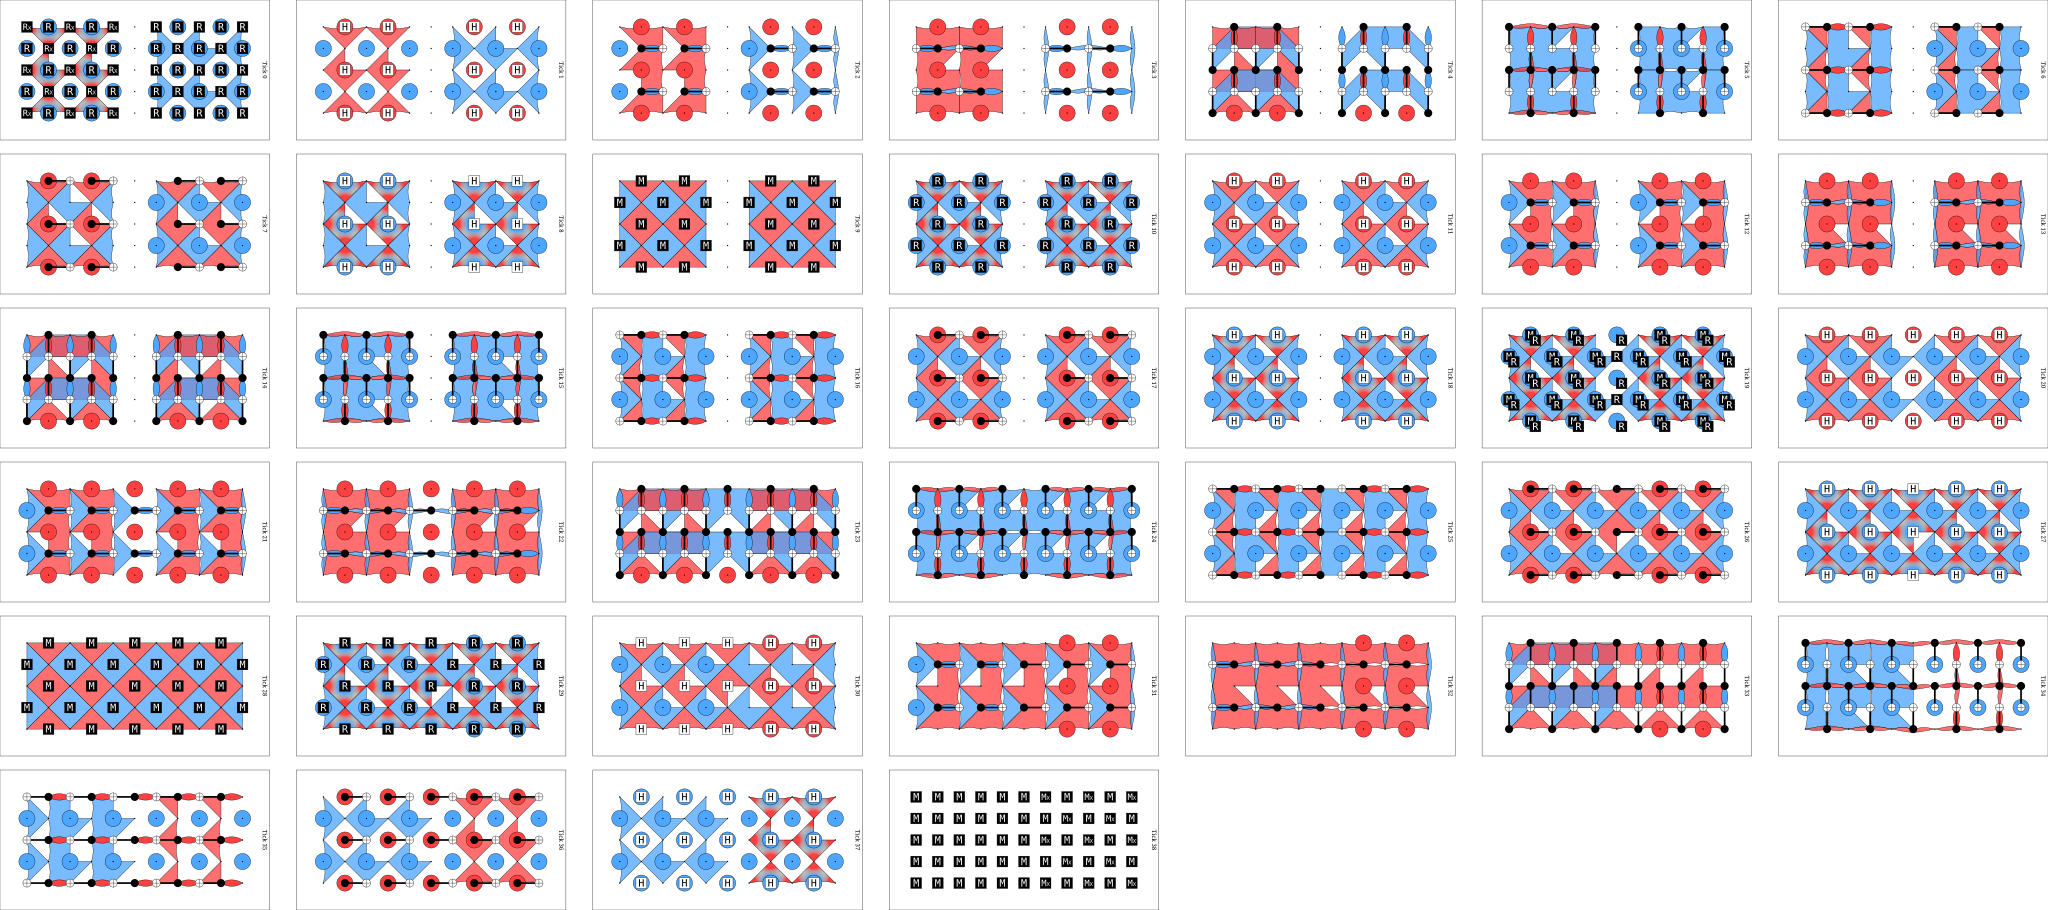

In [8]:
# Example 1: Basic two-patch LS with default settings
experiment_xx = TwoPatchLSExperiment(
    patch1_config={"distance": 3},
    patch2_config={"distance": 3},
    offset=(6, 0),
    interaction_type="XX",
    initial_state_patch1="X", # "X", "Z"
    initial_state_patch2="Z", # "X", "Z"
    measure_state_patch1="Z",
    measure_state_patch2="X",
    rounds=2
    # rotate_patch1=False
    # We may want adjust the rotation for different visualizations
)

circuit = experiment_xx.build()
print("Number of logical observables: ", circuit.num_observables)
# circuit.diagram("detslice-with-ops-svg")
circuit.diagram("detslice-with-ops-svg") # "L1"

## Example 2: ZZ Measurement on $|00\rangle$, $|0+\rangle$, $|+0\rangle$, $|++\rangle$

In [9]:
# Example 2: ZZ interaction with different initial states
experiment_zz = TwoPatchLSExperiment(
    patch1_config={"distance": 3},
    patch2_config={"distance": 3},
    offset=(0, 6),
    interaction_type="ZZ",
    initial_state_patch1="Z", # "X", "Z"
    initial_state_patch2="Z", # "X", "Z"
    measure_state_patch1="Z",
    measure_state_patch2="Z",
    rounds=2
)

circuit_zz = experiment_zz.build()
# circuit_zz.diagram("detslice-with-ops-svg")
# circuit_zz.diagram("detslice-with-ops-svg", filter_coords=["L0"]) # "L1"

Creating patches...
Rotating patch1 by pi...
Setting up QEC system...
Registering coupler with interaction type ZZ...
Writing coordinates...
Initializing code patch data qubits...
Building 2 rounds of syndrome extraction (before coupler activation)...
Activating the coupler...
Initializing coupler data qubits...
Building 2 rounds of syndrome extraction (after coupler activation)...
Measuring data qubits...


## Example 3: Rectangular Patches with Different Sizes, XX Measurment on $|++\rangle$

Creating patches...
Rotating patch1 by pi...
Setting up QEC system...
Registering coupler with interaction type XX...
Writing coordinates...
Initializing code patch data qubits...
Building 2 rounds of syndrome extraction (before coupler activation)...
Activating the coupler...
Initializing coupler data qubits...
Building 2 rounds of syndrome extraction (after coupler activation)...
Measuring data qubits...


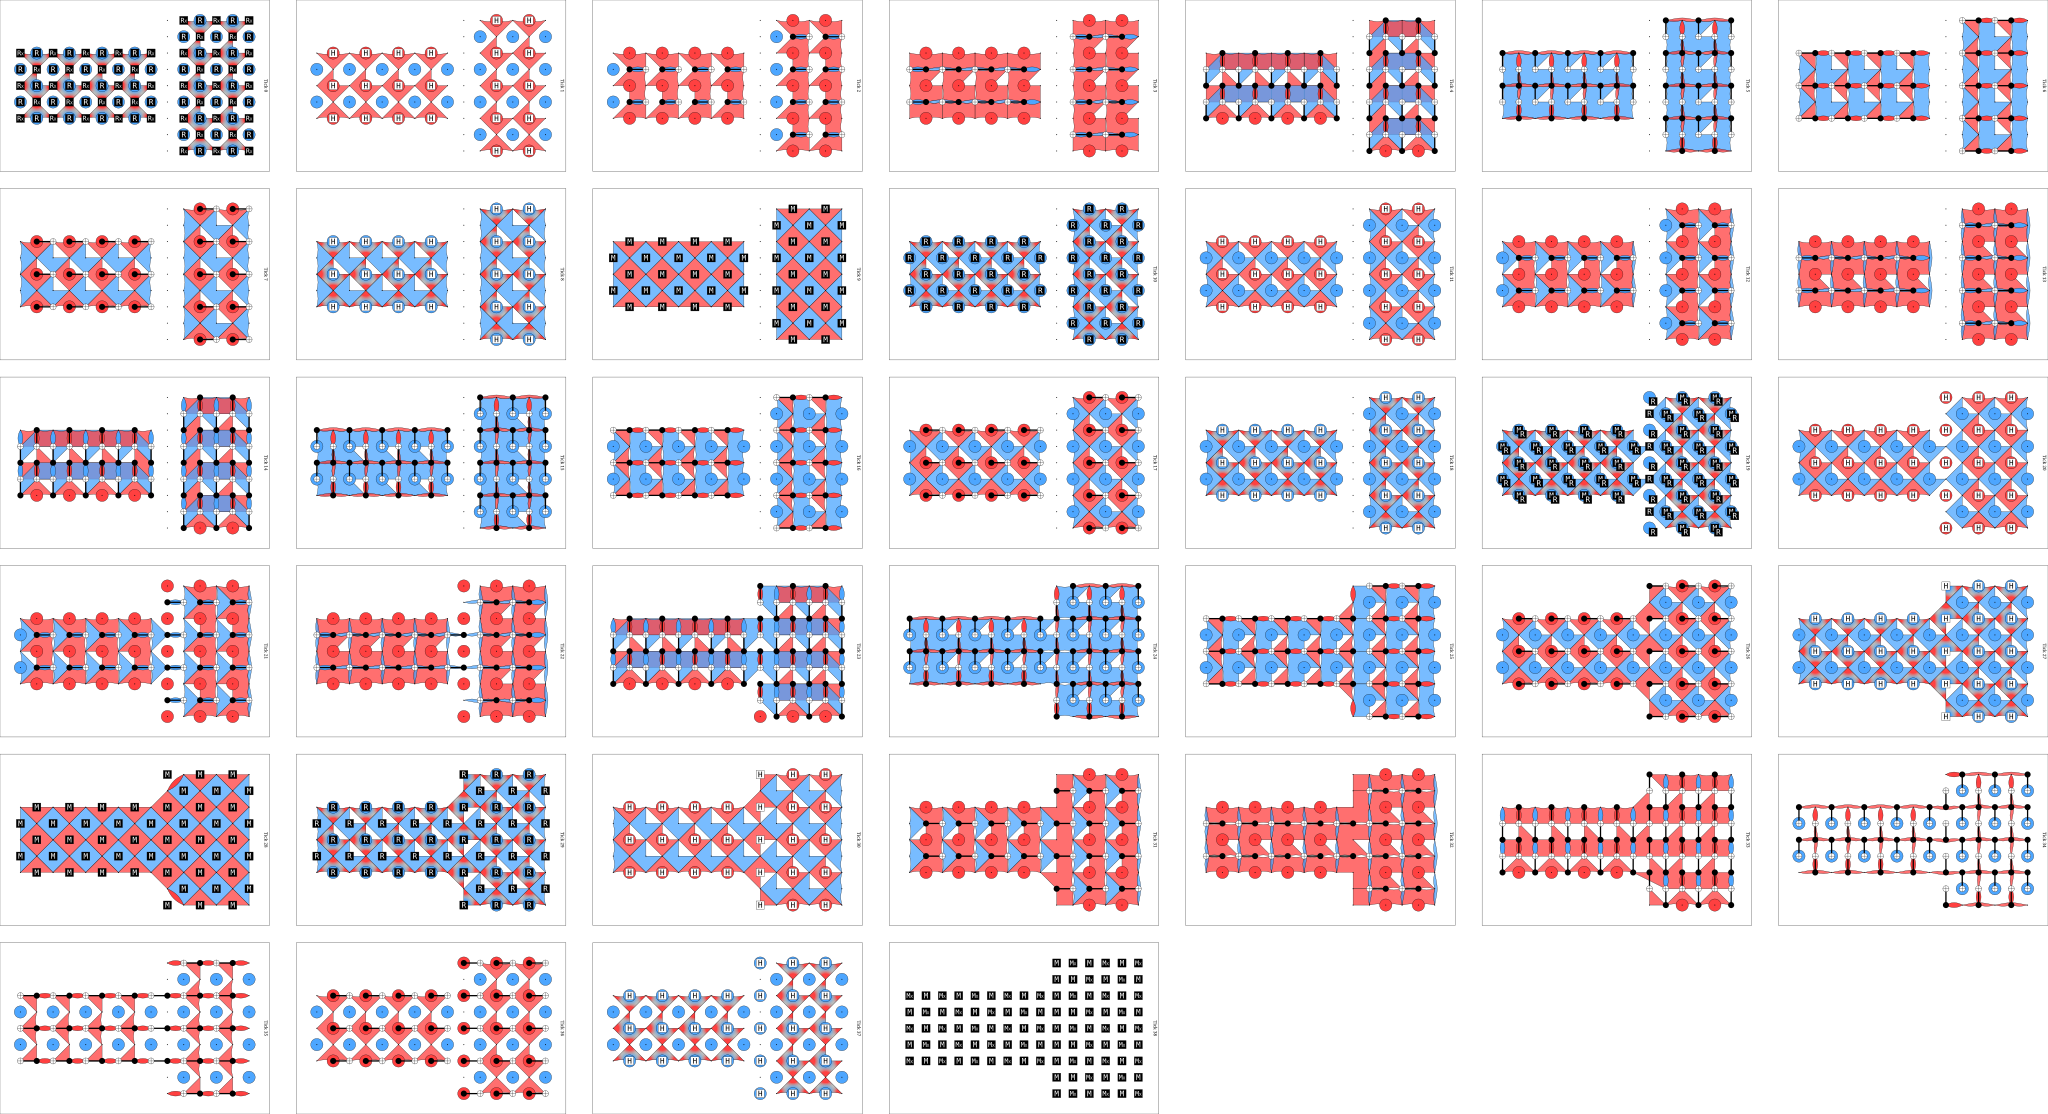

In [10]:
# Example 3: Different patch sizes (rectangular patches)
experiment_rect = TwoPatchLSExperiment(
    patch1_config={"distance_z": 5, "distance_x": 3},
    patch2_config={"distance_z": 3, "distance_x": 5},
    offset=(10, -2), # (10, -2), (10, -0)
    interaction_type="XX",
    initial_state_patch1="X",
    initial_state_patch2="X",
    measure_state_patch1="X",
    measure_state_patch2="X",
    rounds=2
)

circuit_rect = experiment_rect.build()
circuit_rect.diagram("detslice-with-ops-svg")
# circuit_rect.diagram("detslice-with-ops-svg", filter_coords=["L0"]) # "L1"

## Example 4: Logical Error Rate vs $p$

Circuit-level depolarizing noise, `rounds = d`, PyMatching decoder. Below threshold the LER is suppressed with code distance — the unrotated two-patch merge is error-correcting. (Quick demo sweep; full high-statistics version: `benchmarks/logical_ops/` gates `TwoPatchLS_XX` / `TwoPatchLS_ZZ`.)

d=3: 1e-03->2.9e-03  2e-03->1.4e-02  3e-03->3.1e-02  5e-03->8.0e-02  7e-03->1.4e-01  1e-02->2.3e-01


d=5: 1e-03->6.3e-04  2e-03->3.4e-03  3e-03->1.4e-02  5e-03->6.4e-02  7e-03->1.5e-01  1e-02->3.2e-01


d=7: 1e-03->2.5e-05  2e-03->9.0e-04  3e-03->3.6e-03  5e-03->4.3e-02  7e-03->1.6e-01  1e-02->3.8e-01


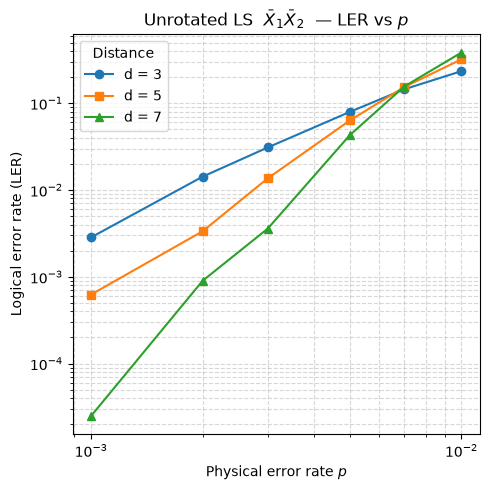

In [2]:
import io, contextlib
import pymatching
import matplotlib.pyplot as plt
from lightstim.noise.config import NoiseConfig

def ler(d, p, max_shots=40000, max_errors=50, batch=20000):
    noise = NoiseConfig(p_meas=p, p_reset=p, p_1q=p, p_2q=p, p_idle=p)
    exp = TwoPatchLSExperiment(
        patch1_config={"distance": d}, patch2_config={"distance": d},
        offset=(4 * d - 2, 0), interaction_type="XX",        # unrotated XX = left-right
        initial_state_patch1="X", initial_state_patch2="Z",
        measure_state_patch1="Z", measure_state_patch2="X",
        rounds=d, noise_params=noise, noise_model="circuit_level",
    )
    with contextlib.redirect_stdout(io.StringIO()):
        circ = exp.build()
    matcher = pymatching.Matching.from_detector_error_model(
        circ.detector_error_model(decompose_errors=True))
    sampler = circ.compile_detector_sampler()
    shots = errors = 0
    while shots < max_shots and errors < max_errors:
        n = min(batch, max_shots - shots)
        dets, obs = sampler.sample(n, separate_observables=True)
        errors += int(np.sum(np.any(matcher.decode_batch(dets) != obs, axis=1)))
        shots += n
    return errors / shots

ps = [1e-3, 2e-3, 3e-3, 5e-3, 7e-3, 1e-2]
plt.figure(figsize=(5, 5))
for d, mk in [(3, "o"), (5, "s"), (7, "^")]:
    ys = [ler(d, p) for p in ps]
    plt.loglog(ps, ys, marker=mk, label=f"d = {d}")
    print(f"d={d}: " + "  ".join(f"{p:.0e}->{y:.1e}" for p, y in zip(ps, ys)))

plt.xlabel("Physical error rate $p$")
plt.ylabel("Logical error rate (LER)")
plt.title(r"Unrotated LS  $\bar X_1 \bar X_2$  — LER vs $p$")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(title="Distance"); plt.tight_layout(); plt.show()